# Parte 2 — Análise Exploratória (EDA)

Objetivo da Parte 2 é entender a base que construímos na Parte 1 antes de
tomar qualquer decisão de modelagem. Como o projeto pede que a
EDA apoie as escolhas da etapa seguinte, cada seção aqui termina
apontando uma decisão seguir.

Perguntas que guiam esta análise:
- O target está balanceado?
- Quais variáveis categóricas parecem se relacionar com o resultado?
- Existe padrão territorial (UF, região)?
- Onde estão concentrados os valores faltantes, e isso muda por ano?
- As variáveis numéricas se correlacionam entre si (redundância) ou com o
  target?


## 1. Carregar a base

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.utils.paths import GOLD_DIR

pd.set_option("display.max_columns", 50)

df = pd.read_parquet(GOLD_DIR / "base_alunos_modelagem.parquet")
print(f"{len(df):,} linhas, {df.shape[1]} colunas")
df.head()


3,867,999 linhas, 30 colunas


,ano,id_municipio,id_escola,id_aluno,caderno,rede,presenca,preenchimento_caderno,alfabetizado,peso_aluno,sigla_uf,alfabetizado_flag,taxa_alfabetizacao_municipio_ano_anterior,media_portugues_municipio_ano_anterior,taxa_alfabetizacao_uf_ano_anterior,media_portugues_uf_ano_anterior,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,meta_alfabetizacao_2024_uf,meta_alfabetizacao_2025_uf,meta_alfabetizacao_2026_uf,meta_alfabetizacao_2027_uf,meta_alfabetizacao_2028_uf,meta_alfabetizacao_2029_uf,meta_alfabetizacao_2030_uf
0,2024,3204906,60022379,32028878,43,Municipal,Ausente,Prova não preenchida,Não,NaN,ES,0,67.19,751.3222,67.52,753.1398,69.26,71.26,73.18,75.01,76.76,78.43,80.0,69.9,71.8,73.6,75.3,76.9,78.5,80.0
1,2024,3205309,60022713,32007513,43,Municipal,Presente,Prova preenchida,Sim,1.09,ES,1,65.88,751.3438,67.52,753.1398,68.18,70.39,72.51,74.54,76.46,78.28,80.0,69.9,71.8,73.6,75.3,76.9,78.5,80.0
2,2023,1302603,60000703,13024170,1,Estadual,Ausente,Prova não preenchida,Não,NaN,AM,0,NaN,NaN,NaN,NaN,56.80,61.28,65.58,69.63,73.41,76.87,80.0,56.8,61.3,65.6,69.6,73.4,76.9,80.0
3,2023,1501808,60001609,15031556,1,Municipal,Ausente,Prova não preenchida,Não,NaN,PA,0,NaN,NaN,NaN,NaN,49.78,55.57,61.21,66.57,71.53,76.02,80.0,53.6,58.7,63.6,68.2,72.5,76.5,80.0
4,2023,1502806,60001620,15041830,1,Municipal,Ausente,Prova não preenchida,Não,NaN,PA,0,NaN,NaN,NaN,NaN,32.28,40.46,49.20,58.00,66.31,73.73,80.0,53.6,58.7,63.6,68.2,72.5,76.5,80.0


## 2. Visão geral: tipos e valores faltantes

Visão geral da base.


In [2]:
resumo = pd.DataFrame({
    "dtype": df.dtypes,
    "nulos": df.isnull().sum(),
    "nulos_%": (df.isnull().mean() * 100).round(1),
})
resumo


,dtype,nulos,nulos_%
ano,Int64,0,0.0
id_municipio,object,0,0.0
id_escola,object,0,0.0
id_aluno,object,0,0.0
caderno,object,0,0.0
rede,object,0,0.0
presenca,object,0,0.0
preenchimento_caderno,object,0,0.0
alfabetizado,object,0,0.0
peso_aluno,float64,513338,13.3


As colunas de contexto (`_municipio_ano_anterior`, `_uf_ano_anterior`) e as
metas tem nulos.. Isso já era esperado da Parte 1. O resto da base está completa.


## 3. O target: `alfabetizado`

Já vimos isso rapidamente na Parte 1, mas aqui olhamos com mais detalhes...  
Inclusive se o balanceamento se mantém igual em cada ano.


In [3]:
df["alfabetizado"].value_counts(normalize=True).round(3)


alfabetizado
Sim    0.513
Não    0.487
Name: proportion, dtype: float64

In [4]:
balanco_por_ano = (
    df.groupby("ano")["alfabetizado_flag"]
    .mean()
    .rename("taxa_de_alfabetizados")
    .round(3)
)
balanco_por_ano


ano
2023    0.502
2024    0.522
Name: taxa_de_alfabetizados, dtype: float64

O target está bem balanceado (perto de 50/50) tanto no total
quanto em cada ano separado. Não vamos
precisar de técnicas de balanceamento de classe (como oversampling) na
Parte 3, o que simplifica o pipeline.


## 4. Variáveis categóricas x target

Para cada categórica, olhamos duas coisas: quão comum é cada categoria, e
qual a taxa de alfabetização dentro dela. Se a taxa varia bastante entre
categorias, a variável tem poder preditivo, se fica parecida com a média
geral (~51%) em todas as categorias, ela provavelmente não ajuda muito.


In [5]:
def taxa_por_categoria(coluna):
    tab = (
        df.groupby(coluna)["alfabetizado_flag"]
        .agg(qtd_alunos="count", taxa_alfabetizados="mean")
        .sort_values("qtd_alunos", ascending=False)
    )
    tab["taxa_alfabetizados"] = tab["taxa_alfabetizados"].round(3)
    return tab

taxa_por_categoria("rede")


,qtd_alunos,taxa_alfabetizados
rede,,
Municipal,3432576,0.511
Estadual,435398,0.532
Privada,25,0.640


In [6]:
taxa_por_categoria("presenca")


,qtd_alunos,taxa_alfabetizados
presenca,,
Presente,3355846,0.591
Ausente,512153,0.000


In [7]:
taxa_por_categoria("preenchimento_caderno")


,qtd_alunos,taxa_alfabetizados
preenchimento_caderno,,
Prova preenchida,3354661,0.592
Prova não preenchida,513338,0.000


**Leitura:**
- `rede`: a taxa de alfabetização varia entre Municipal, Estadual e
  Privada — sinal de que é uma feature com poder preditivo real, não só
  ruído.
- `presenca` e `preenchimento_caderno`: alunos ausentes ou com prova não
  preenchida obviamente não têm como ser avaliados como alfabetizados —
  são categorias praticamente deterministas do resultado. Isso não é
  leakage (a presença do aluno é conhecida *antes* do resultado, não é
  derivada dele), mas precisa ser citado no README como uma variável
  fortemente explicativa por razão óbvia, não por padrão pedagógico
  interessante.


## 5. Padrão territorial (UF)

O enunciado pergunta explicitamente "quais municípios/regiões apresentam
maior risco educacional". Município tem granularidade demais pra
visualizar direto (milhares); começamos por UF.


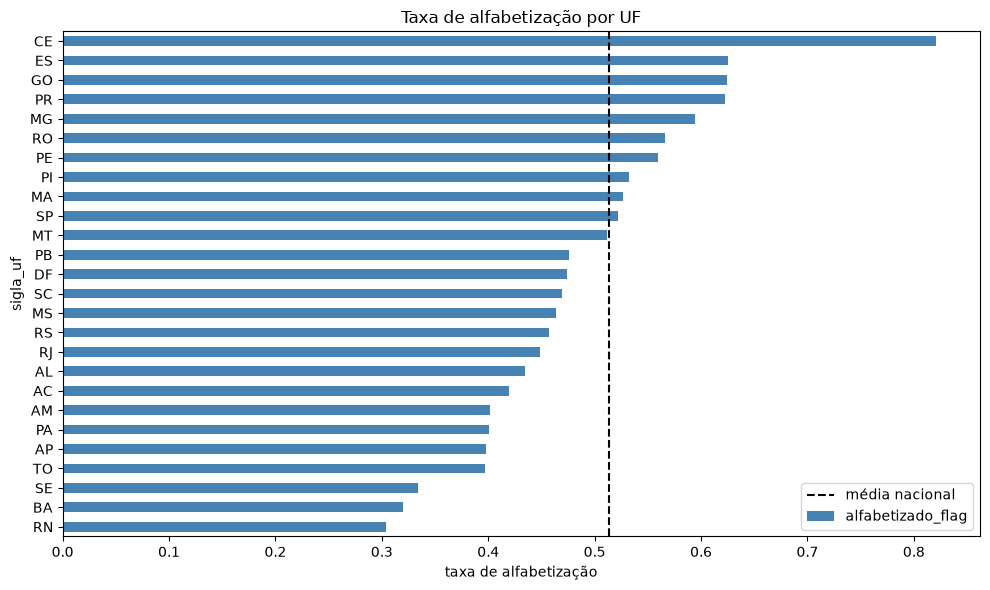

In [8]:
taxa_uf = (
    df.groupby("sigla_uf")["alfabetizado_flag"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
taxa_uf.plot(kind="barh", ax=ax, color="steelblue")
ax.axvline(df["alfabetizado_flag"].mean(), color="black", linestyle="--", label="média nacional")
ax.set_xlabel("taxa de alfabetização")
ax.set_title("Taxa de alfabetização por UF")
ax.legend()
plt.tight_layout()
plt.show()


**Leitura:** existe variação real entre estados — alguns ficam
consistentemente acima da média nacional, outros abaixo. Isso confirma
que `sigla_uf` (e o contexto de UF que trouxemos na Parte 1) é uma
dimensão relevante para o modelo, e também já começa a responder a
pergunta de negócio sobre risco regional.


## 6. Variáveis numéricas de contexto

Essas são as que trouxemos na Parte 1 (indicadores do município/UF do ano
anterior). Queremos ver se elas realmente diferem entre quem foi
alfabetizado e quem não foi — só faz sentido usá-las como feature se
diferirem.


In [9]:
colunas_numericas = [
    "taxa_alfabetizacao_municipio_ano_anterior",
    "media_portugues_municipio_ano_anterior",
    "taxa_alfabetizacao_uf_ano_anterior",
    "media_portugues_uf_ano_anterior",
]

df.groupby("alfabetizado")[colunas_numericas].mean().round(2)


,taxa_alfabetizacao_municipio_ano_anterior,media_portugues_municipio_ano_anterior,taxa_alfabetizacao_uf_ano_anterior,media_portugues_uf_ano_anterior
alfabetizado,,,,
Não,52.52,739.97,54.25,742.09
Sim,59.77,749.67,58.27,747.81


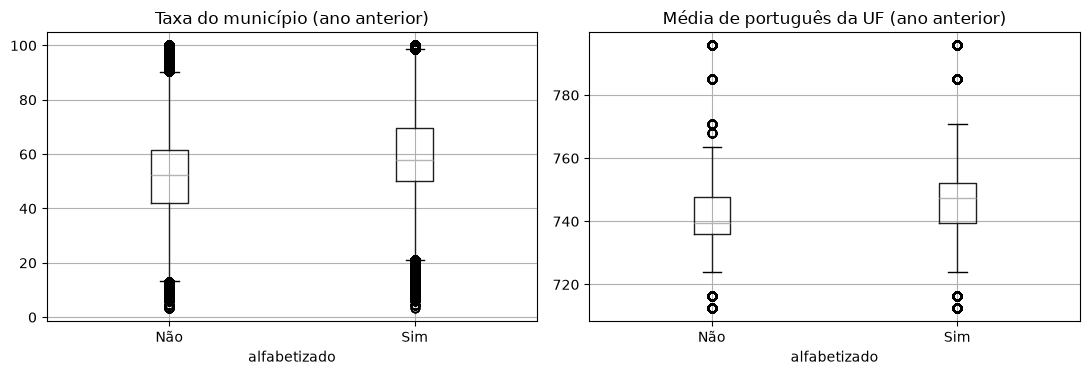

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df.boxplot(column="taxa_alfabetizacao_municipio_ano_anterior", by="alfabetizado", ax=axes[0])
axes[0].set_title("Taxa do município (ano anterior)")
axes[0].set_xlabel("alfabetizado")
df.boxplot(column="media_portugues_uf_ano_anterior", by="alfabetizado", ax=axes[1])
axes[1].set_title("Média de português da UF (ano anterior)")
axes[1].set_xlabel("alfabetizado")
plt.suptitle("")
plt.tight_layout()
plt.show()


Os grupos "Sim" e "Não" têm medianas visivelmente diferentes
nessas variáveis — alunos de municípios/UFs com histórico melhor têm mais
chance de serem classificados como alfabetizados. Isso confirma que vale
a pena manter essas features (com a imputação de nulos que vamos definir
na Parte 3 para cobrir os alunos de 2023).


## 7. Correlação entre as variáveis numéricas

Além de correlacionar com o target, precisamos checar se as próprias
features numéricas são redundantes entre si (ex: taxa do município e taxa
da UF podem estar carregando informação parecida).


In [11]:
colunas_corr = colunas_numericas + ["alfabetizado_flag"]
corr = df[colunas_corr].corr().round(2)
corr


,taxa_alfabetizacao_municipio_ano_anterior,media_portugues_municipio_ano_anterior,taxa_alfabetizacao_uf_ano_anterior,media_portugues_uf_ano_anterior,alfabetizado_flag
taxa_alfabetizacao_municipio_ano_anterior,1.00,0.94,0.71,0.66,0.24
media_portugues_municipio_ano_anterior,0.94,1.00,0.67,0.72,0.25
taxa_alfabetizacao_uf_ano_anterior,0.71,0.67,1.00,0.93,0.19
media_portugues_uf_ano_anterior,0.66,0.72,0.93,1.00,0.20
alfabetizado_flag,0.24,0.25,0.19,0.20,1.00


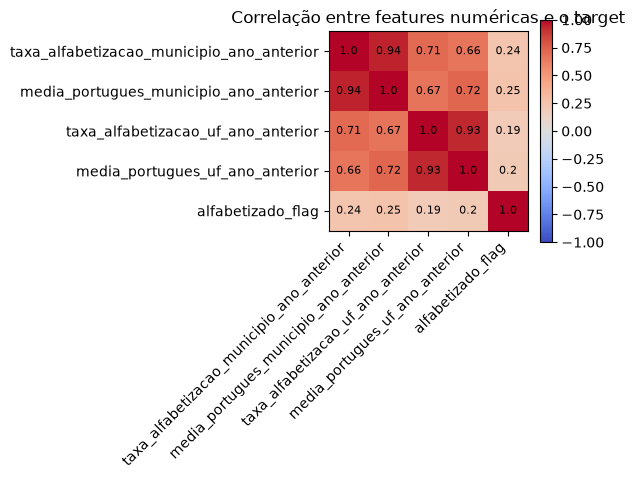

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, corr.iloc[i, j], ha="center", va="center", fontsize=8)
fig.colorbar(im)
ax.set_title("Correlação entre features numéricas e o target")
plt.tight_layout()
plt.show()


Município e UF são moderadamente correlacionados entre si
(esperado — a UF é uma agregação que inclui o município), mas não a ponto
de serem redundantes o suficiente pra descartar um dos dois. Nenhuma
variável isolada tem correlação forte o bastante com o target pra
"resolver sozinha" o problema — o que é o esperado num problema real
(diferente do que vimos com `proficiencia` na Parte 1, que tinha
correlação perfeita por ser a origem do target).


## 8. Conclusões da EDA

- Target balanceado (~51/49, estável por ano): não precisa de técnica
  de balanceamento de classe.
- Categóricas com sinal real: `rede`, `sigla_uf`, `presenca`,
  `preenchimento_caderno` — todas vão para o pipeline com encoding.
- Numéricas de contexto têm relação clara com o target*: mantemos
  `taxa_alfabetizacao_*` e `media_portugues_*` (município e UF), com
  imputação de nulos (concentrados em 2023).
- Não há redundância forte entre município e UF a ponto de eliminar
  uma das duas escalas geográficas.
- `id_municipio`, `id_escola`, `id_aluno`, `caderno`: identificadores
  ou quase-identificadores (alta cardinalidade), não entram como feature
  direta — servem só de chave para os merges já feitos.

